In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
data = pd.read_csv("city_day.csv")
data.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [4]:
missing = data.isnull().sum()
print(missing[missing > 0])

PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [5]:
data.fillna(data.median(numeric_only=True), inplace=True)

In [6]:
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

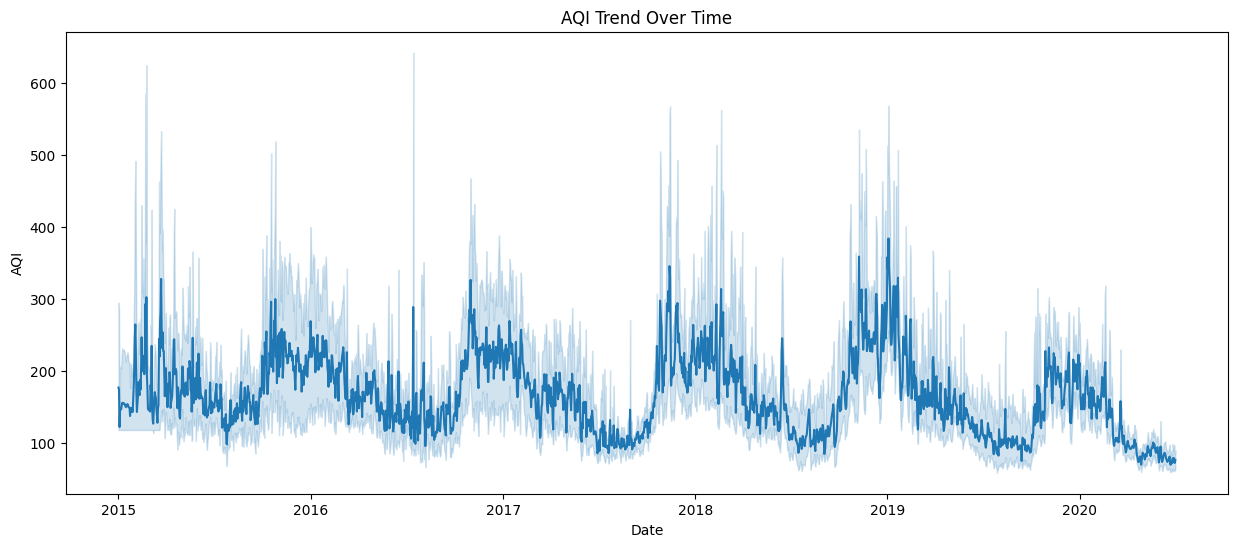

In [7]:
plt.figure(figsize=(15,6))
sns.lineplot(data=data, x='Date', y='AQI')
plt.title("AQI Trend Over Time")
plt.show()

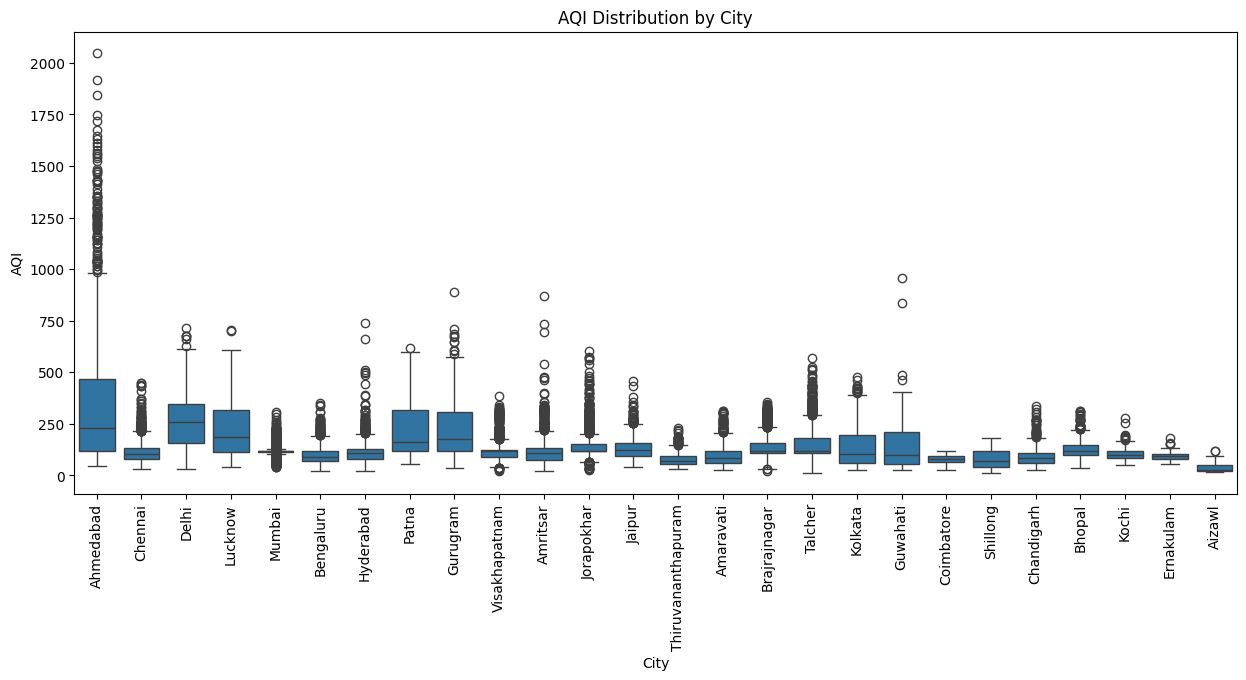

In [8]:
plt.figure(figsize=(15,6))
sns.boxplot(data=data, x='City', y='AQI')
plt.xticks(rotation=90)
plt.title("AQI Distribution by City")
plt.show()

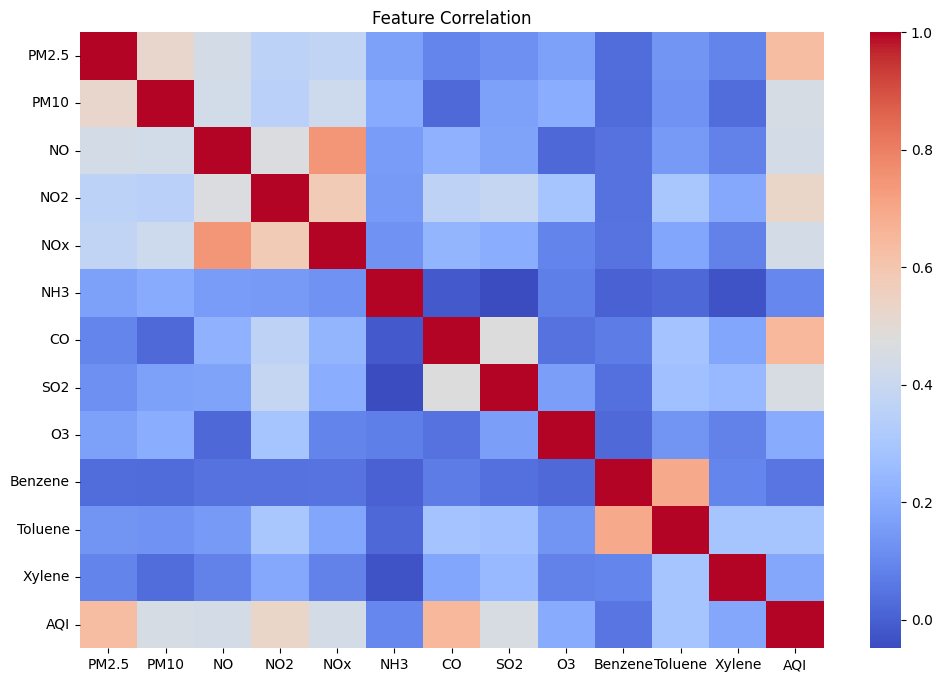

In [9]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [10]:
features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 
            'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

X = data[features]
y = data['AQI']

In [11]:
train_size = int(len(data) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [14]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [15]:
import tensorflow as tf

nn = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

nn.compile(optimizer='adam', loss='mse')

nn.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2)

y_pred_nn = nn.predict(X_test_scaled)

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 19591.9629 - val_loss: 5198.8613
Epoch 2/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4907.4307 - val_loss: 3947.8291
Epoch 3/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4362.4004 - val_loss: 3566.9084
Epoch 4/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4198.3423 - val_loss: 3455.3162
Epoch 5/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4100.4541 - val_loss: 3397.6104
Epoch 6/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4023.2231 - val_loss: 3188.4331
Epoch 7/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3929.8821 - val_loss: 3094.9758
Epoch 8/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3814.2112 - val_loss: 3107.0115
Epoch 9/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3651.7800 - val_loss: 3078.1863
Epoch 10/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3556.8672 - val_loss: 2871.0081
Epoch 11/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3442.7151 - val_l

In [26]:
results={}
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

In [27]:
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_nn, "Neural Network")


Linear Regression
MAE: 24.856198194183058
RMSE: 40.843189485818144
R2: 0.8099742074502393


NameError: name 'mae' is not defined

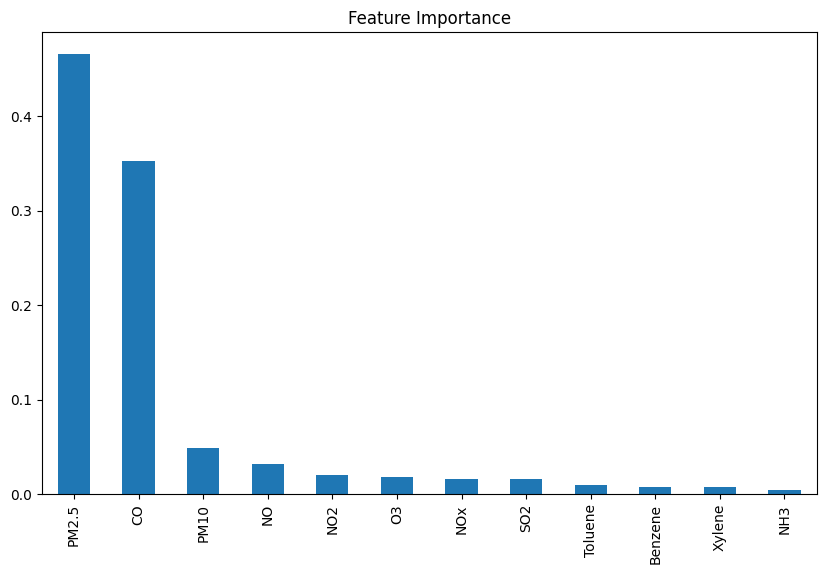

In [28]:
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

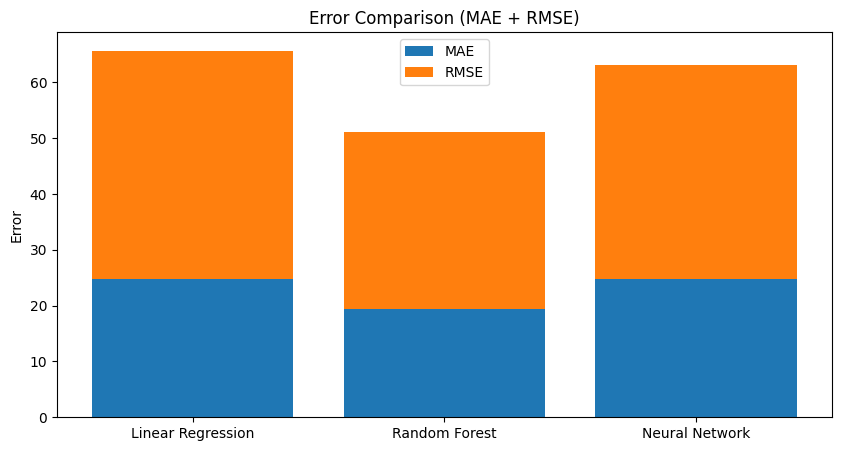

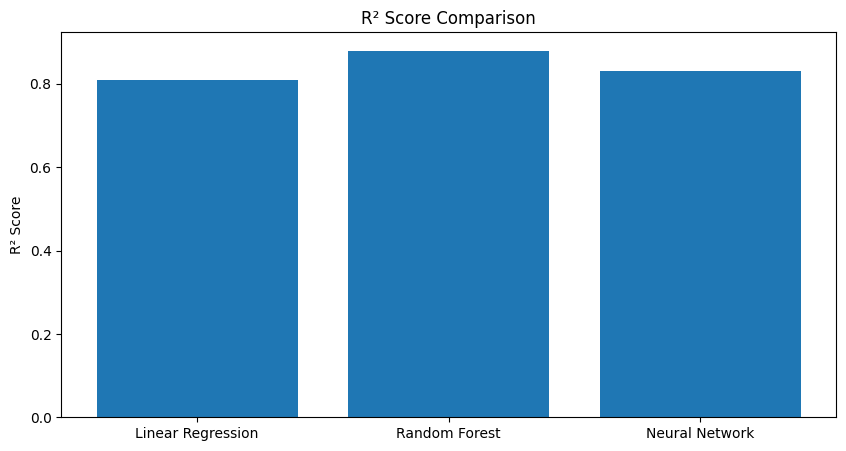

In [30]:
models = ['Linear Regression', 'Random Forest', 'Neural Network']

mae = [24.86, 19.34, 24.76]
rmse = [40.84, 31.86, 38.36]
r2 = [0.81, 0.88, 0.83]

# Error comparison
plt.figure(figsize=(10,5))
plt.bar(models, mae, label='MAE')
plt.bar(models, rmse, bottom=mae, label='RMSE')

plt.title("Error Comparison (MAE + RMSE)")
plt.ylabel("Error")
plt.legend()
plt.show()

# R2 comparison
plt.figure(figsize=(10,5))
plt.bar(models, r2)

plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.show()